In [1]:
import pandas as pd
import numpy as np
import seaborn as sns # for statistical figs

In [2]:
# EDA - basic stats

In [3]:
data = pd.read_csv("C:/Users/anves/OneDrive/Documents/Anvesha/KodeinKGP/RM task/train_data.csv")

In [4]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [6]:
data.shape

(614, 13)

In [7]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# loan amt, loan amt term and credit history data missing for some ppl

In [9]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [10]:
data.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [11]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
# so much data missing.. we will use KNN method to fill 

In [13]:
# some strings with binary can be changed to 0 and 1 so that KNN can fill

In [14]:
# Save Loan_ID separately
loan_ids = data['Loan_ID']

data['Gender'] = data['Gender'].map({
    'Male': 1,
    'Female': 0
})

data['Married'] = data['Married'].map({
    'Yes': 1,
    'No': 0
})

data['Education'] = data['Education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

data['Self_Employed'] = data['Self_Employed'].map({
    'Yes': 1,
    'No': 0
})

data['Property_Area'] = data['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

data['Loan_Status'] = data['Loan_Status'].map({
    'Y': 1,
    'N': 0
})

data['Dependents'] = data['Dependents'].replace('3+', 3)
data['Dependents'] = data['Dependents'].astype(float)

data = data.drop('Loan_ID', axis=1) # bc dtype is object 

In [15]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

data_imputed = imputer.fit_transform(data)

# Convert back to DataFrame
data = pd.DataFrame(
    data_imputed,
    columns=data.columns
)

# Round categorical columns
cat_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Credit_History',
    'Loan_Status'
]

for col in cat_cols:
    data[col] = data[col].round()

data.insert(0, 'Loan_ID', loan_ids)
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [16]:
# missing datas filled 

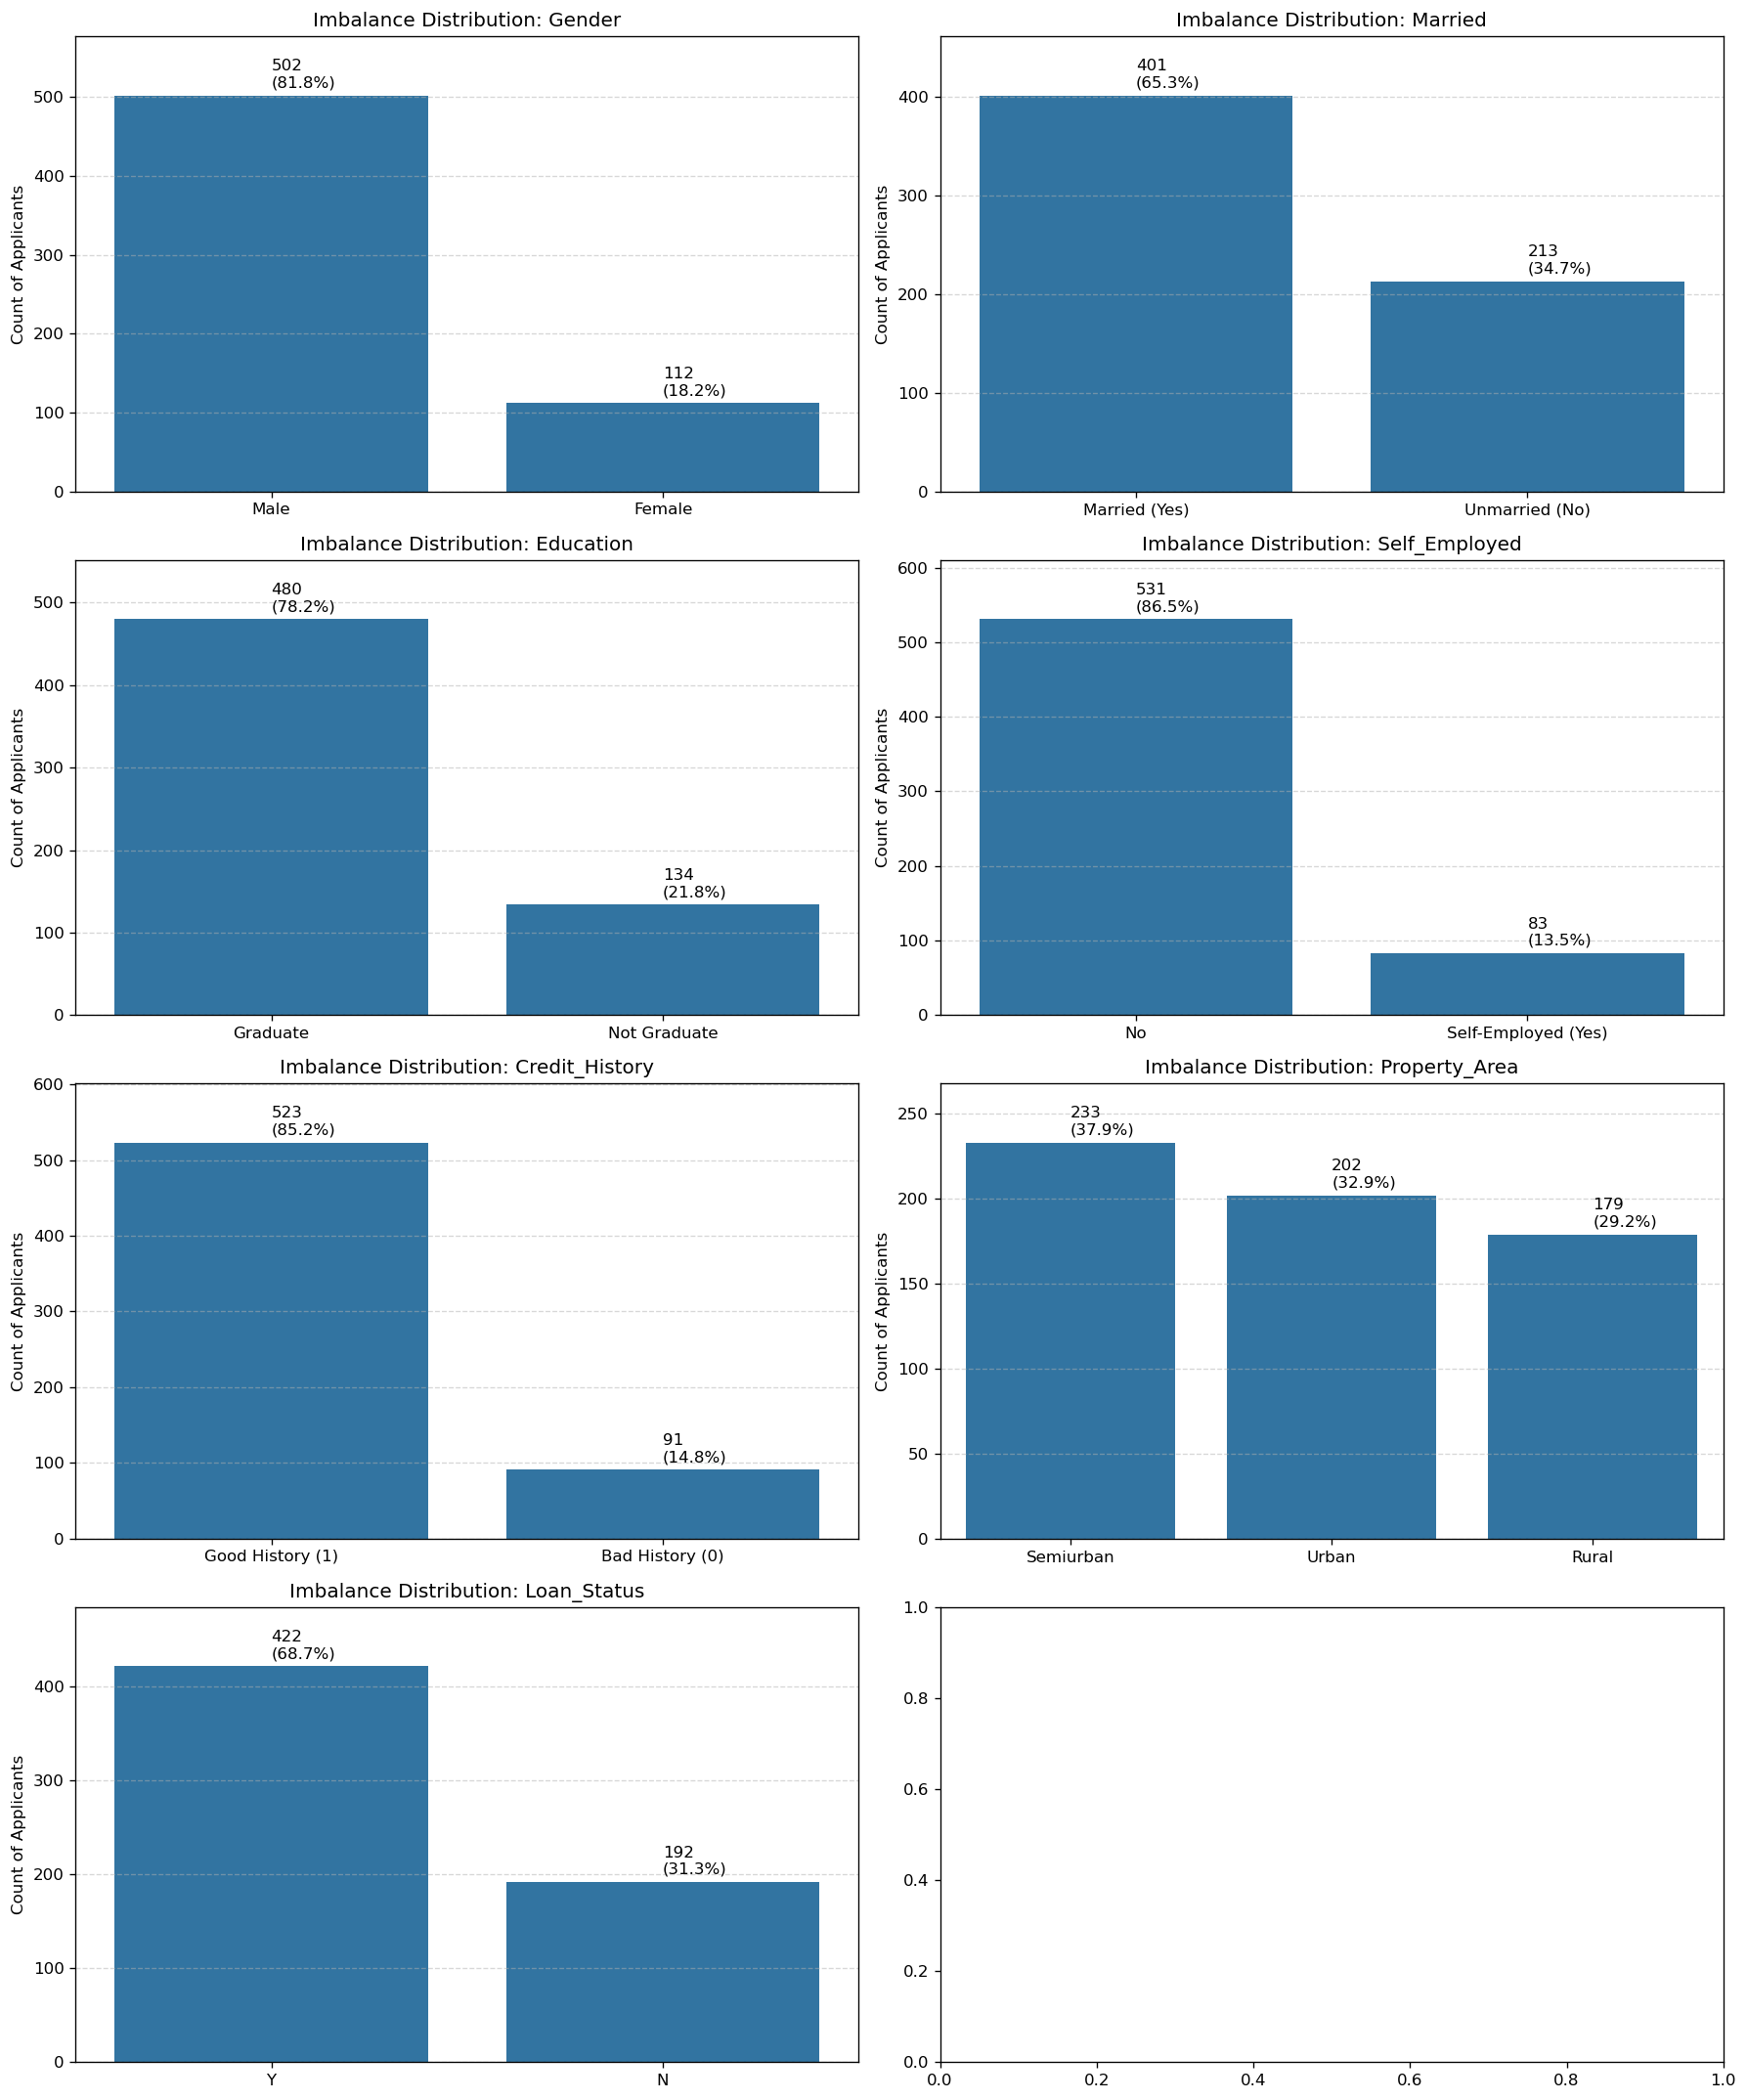

In [17]:
import math
import matplotlib.pyplot as plt

label_mappings = {
    'Gender': {1.0: 'Male', 0.0: 'Female'},
    'Married': {1.0: 'Married (Yes)', 0.0: 'Unmarried (No)'},
    'Education': {1.0: 'Graduate', 0.0: 'Not Graduate'},
    'Self_Employed': {1.0: 'Self-Employed (Yes)', 0.0: 'No'},
    'Property_Area': {2.0: 'Urban', 1.0: 'Semiurban', 0.0: 'Rural'},
    'Credit_History': {1.0: 'Good History (1)', 0.0: 'Bad History (0)'},
    'Dependents': {0.0: '0', 1.0: '1', 2.0: '2', 3.0: '3+'},
    'Loan_Status': {0.0: 'N', 1.0: 'Y'}
}

categorical_cols = [col for col in data.columns if data[col].nunique() <= 5]

cols = 2
rows = math.ceil(len(categorical_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4.5), dpi=120)
axes = axes.flatten() 


for i, col_name in enumerate(categorical_cols):
    plot_data = data[col_name].copy()
    if col_name in label_mappings:
        plot_data = plot_data.map(label_mappings[col_name])
    
    order = plot_data.value_counts().index
    counts = plot_data.value_counts()
    total_samples = len(plot_data)
    sns.countplot(
        x=plot_data, 
        order=order,  
        ax=axes[i], 
    )


    for patch in axes[i].patches:
        height = patch.get_height()
        if height > 0:
            percentage = (height / total_samples) * 100
            axes[i].text(
                patch.get_x() + patch.get_width() / 2.0, 
                height + (max(counts) * 0.02), 
                f'{int(height)}\n({percentage:.1f}%)', 
            )
            
    axes[i].set_title(f"Imbalance Distribution: {col_name}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count of Applicants")
    axes[i].set_ylim(0, max(counts) * 1.15) 
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
# class imbalance -> data is biased in most of the columns, but proceeding with the same because these columns are important and dataset size is small 

In [19]:
customer = data.drop(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'], axis=1)

In [20]:
customer['TotalIncome'] = (   customer['ApplicantIncome'] +
    customer['CoapplicantIncome'] )

data['TotalIncome'] = (   data['ApplicantIncome'] +
    data['CoapplicantIncome'] )

customer = customer.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)


# feature engineering 

In [21]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5) # avg of 5 most similar rows 
customer_imputed = imputer.fit_transform(customer)

In [22]:
customer.head()

,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome
0,147.8,360.0,1.0,1.0,5849.0
1,128.0,360.0,1.0,0.0,6091.0
2,66.0,360.0,1.0,1.0,3000.0
3,120.0,360.0,1.0,1.0,4941.0
4,141.0,360.0,1.0,1.0,6000.0


In [23]:
# scaling not required 

In [24]:
# checking for outliers 

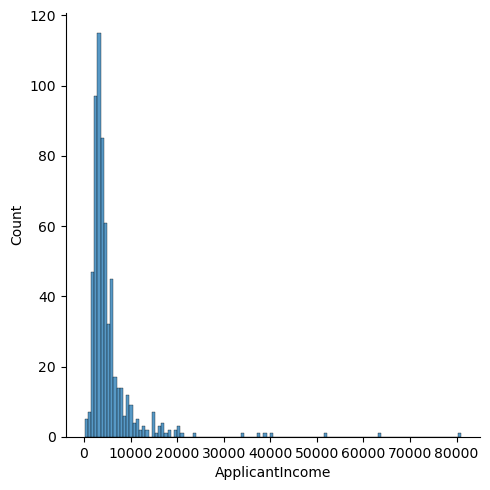

In [25]:
sns.displot(data = data, x='ApplicantIncome')

In [26]:
# 22000 and beyond is outliers 

In [27]:
data['ApplicantIncome']=data['ApplicantIncome'].clip(upper=22000)

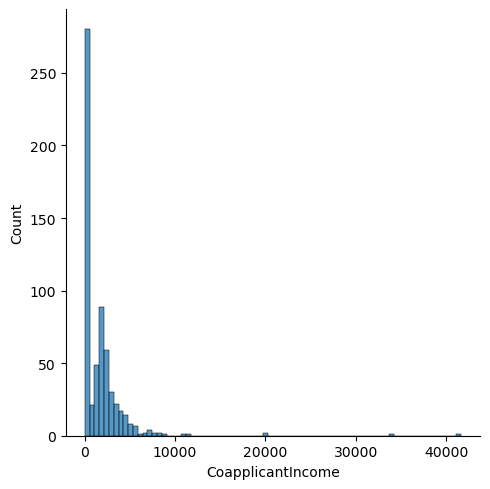

In [28]:
sns.displot(data=data, x='CoapplicantIncome')

In [29]:
# few points after 15000 can be dicarded 

In [30]:
data['CoapplicantIncome']=data['CoapplicantIncome'].clip(upper=15000)

<Axes: >

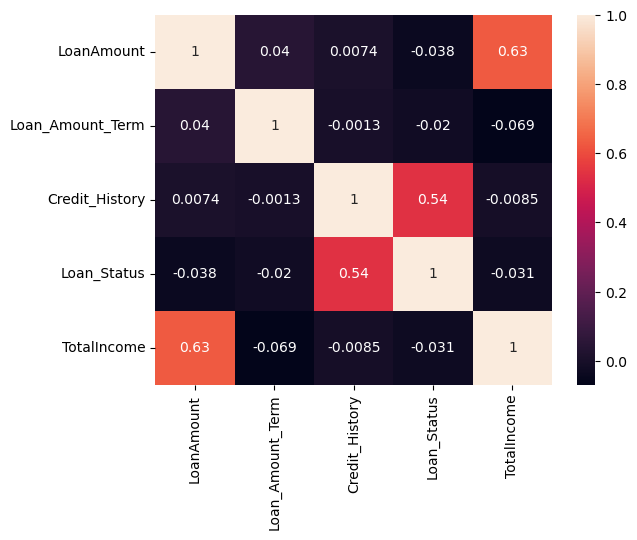

In [31]:
correlation = customer.corr()
sns.heatmap(correlation, xticklabels = correlation.columns, yticklabels = correlation.columns, annot = True)

In [32]:
# target column (Loan_Status) and Credit_History are closely related --> this tells us Credit_History is an important feature 

In [33]:
train_df = data
test_df = pd.read_csv("C:/Users/anves/OneDrive/Documents/Anvesha/KodeinKGP/RM task/test_data.csv")

test_df["Loan_Status"] = test_df["Loan_Status"].map({"Y": 1, "N": 0})

In [34]:
# test data also has missing values 
test_df['Gender'] = test_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

test_df['Married'] = test_df['Married'].map({
    'Yes': 1,
    'No': 0
})

test_df['Education'] = test_df['Education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

test_df['Self_Employed'] =test_df['Self_Employed'].map({
    'Yes': 1,
    'No': 0
})

test_df['Property_Area'] = test_df['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

test_df['Dependents'] = test_df['Dependents'].replace('3+', 3)
test_df['Dependents'] = test_df['Dependents'].astype(float)

test_df = test_df.drop('Loan_ID', axis=1) # bc dtype is object 
test_df.dtypes

test_imputed = imputer.fit_transform(test_df)

# Convert back to DataFrame
test_df = pd.DataFrame(
    test_imputed,
    columns=test_df.columns
)

cat_cols_test = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Credit_History',
]

for col in cat_cols_test:
    test_df[col] = test_df[col].round()

test_df.insert(0, 'Loan_ID', loan_ids)
test_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [35]:
test_df['TotalIncome'] = test_df['ApplicantIncome'] + test_df['CoapplicantIncome']

x_train = train_df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y_train = train_df['Loan_Status'].astype(int)


x_test = test_df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y_test = test_df['Loan_Status'].astype(int)

# force the test columns to be in the exact same order as the training columns
x_test = x_test[x_train.columns]

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train shape: (614, 12)
x_test shape: (367, 12)


In [36]:
# decision trees 

In [37]:
# unpruned tree

In [38]:
from sklearn.tree import DecisionTreeClassifier
unpruned_tree = DecisionTreeClassifier().fit(x_train_scaled, y_train)

In [39]:
score_train_unpruned_tree = unpruned_tree.score(x_train_scaled, y_train)
score_test_unpruned_tree = unpruned_tree.score(x_test_scaled, y_test)

In [40]:
train_scores = [score_train_unpruned_tree]
test_scores = [score_test_unpruned_tree]
model_list = ['unpruned_tree']
score_dict = {
    'train_score':train_scores,
    'test_score':test_scores,
}
data_new_score = pd.DataFrame(score_dict, index=model_list)
data_new_score

,train_score,test_score
unpruned_tree,1.0,0.72752


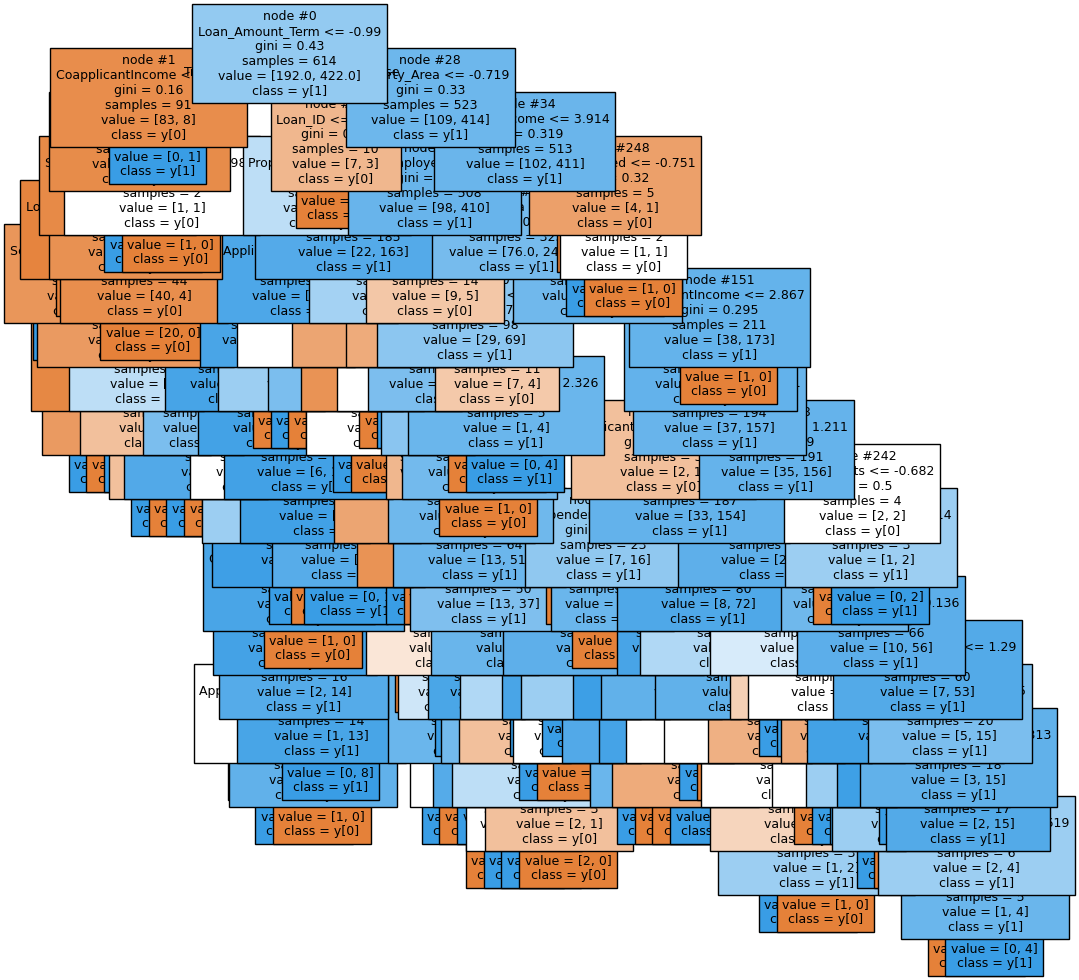

In [41]:
from sklearn.tree import plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
plot_tree(unpruned_tree, feature_names=data.columns, filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [42]:
# overfitted model -> not desirable 

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

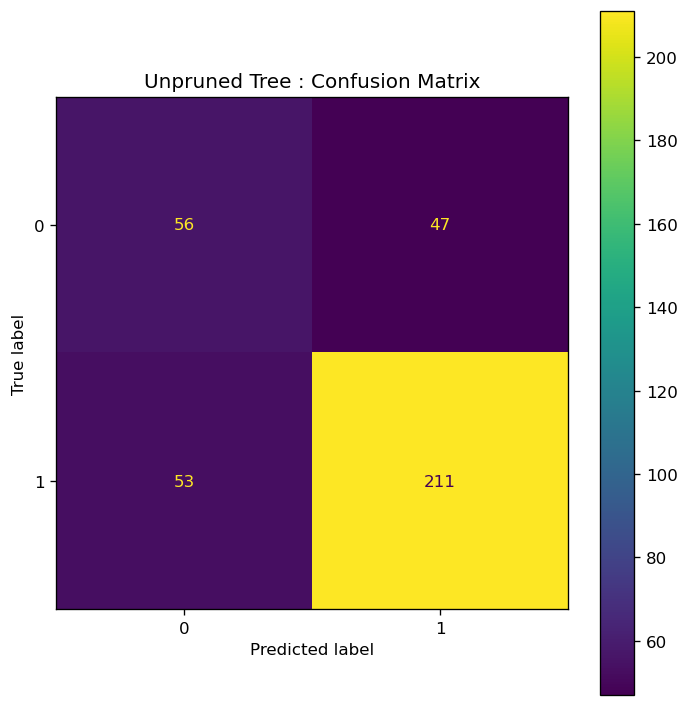

In [44]:
y_pred = unpruned_tree.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unpruned_tree.classes_)

disp.plot(
    ax=ax
)

ax.set_title("Unpruned Tree : Confusion Matrix")
plt.tight_layout()
plt.show()

In [45]:
# pruned tree 

In [46]:
# entropy

In [47]:
entropy_tree = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(x_train_scaled, y_train)

In [48]:
score_train_entropy_tree = entropy_tree.score(x_train_scaled, y_train)
score_test_entropy_tree = entropy_tree.score(x_test_scaled, y_test)
train_scores_entropy = [score_train_entropy_tree]
test_scores_entropy = [score_test_entropy_tree]
model_list_entropy = ['entropy_tree']
score_dict_entropy = {
    'train_score_entropy':train_scores_entropy,
    'test_score_entropy':test_scores_entropy,
}
data_new_score_entropy = pd.DataFrame(score_dict_entropy, index=model_list_entropy)
data_new_score_entropy

,train_score_entropy,test_score_entropy
entropy_tree,1.0,0.743869


In [49]:
# accuracy increased a little bit 

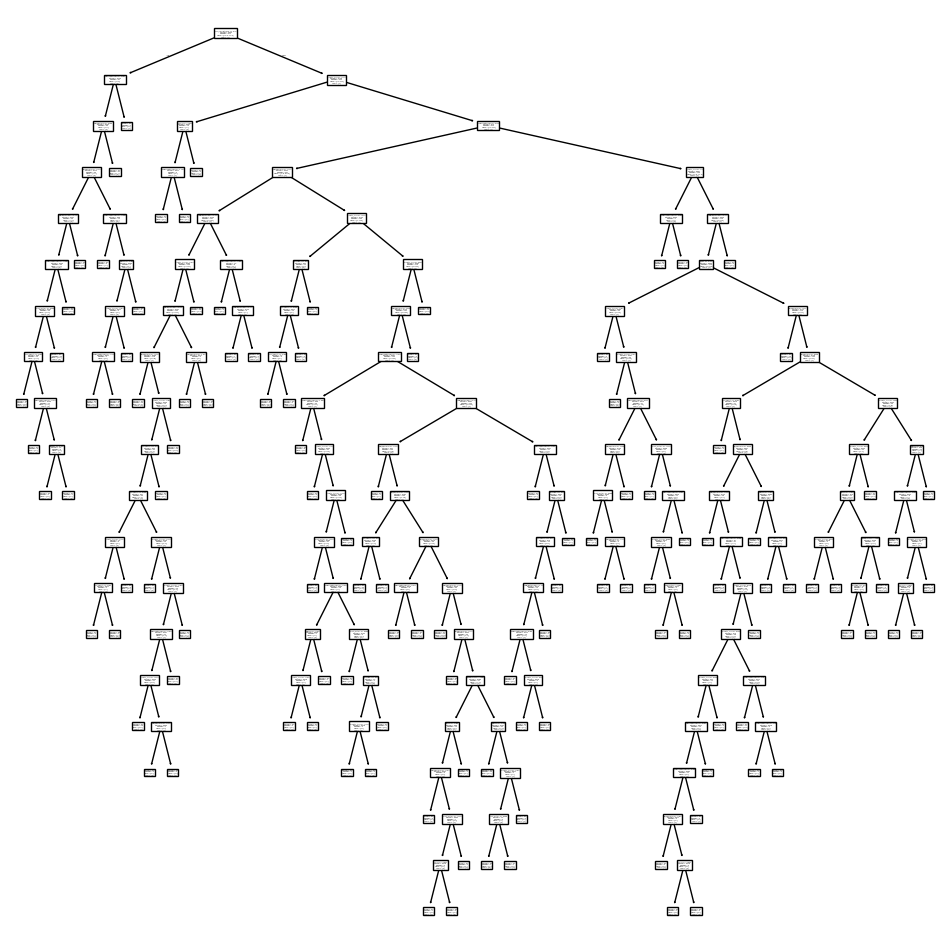

In [50]:
plt.figure(figsize = (12,12))
plot_tree(entropy_tree, feature_names=data.columns, node_ids=True, class_names=True)
plt.show()

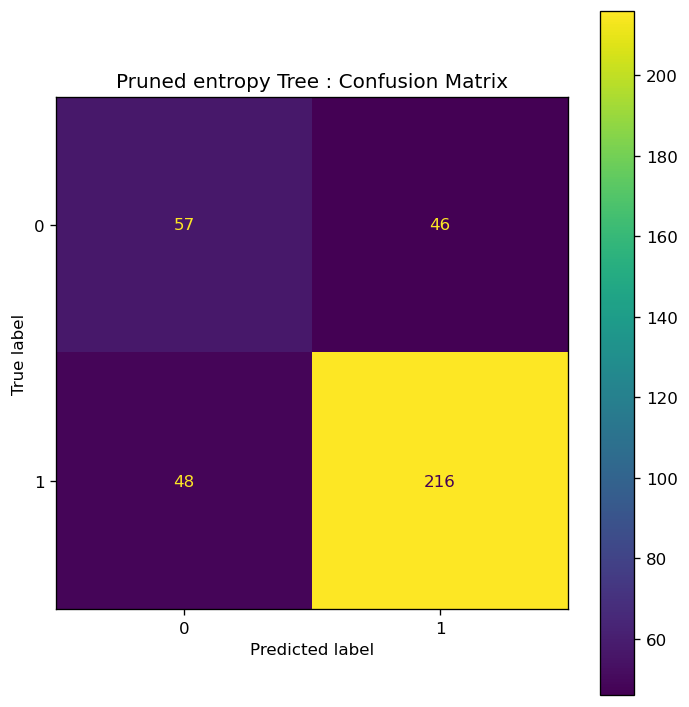

In [51]:
y_pred = entropy_tree.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=entropy_tree.classes_)

disp.plot(
    ax=ax
)

ax.set_title("Pruned entropy Tree : Confusion Matrix")
plt.tight_layout()
plt.show()

In [52]:
# pruned tree - minimising depth

In [53]:
# tried multiple max_depth values... 6 gave the most accuracy.. >6 and <6 decreased the model's accuracy

In [54]:
pruned_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 6, min_samples_split = 10, min_samples_leaf = 10, max_features = 6, random_state=42).fit(x_train_scaled, y_train)

In [55]:
score_train_pruned_tree = pruned_tree.score(x_train_scaled, y_train)
score_test_pruned_tree = pruned_tree.score(x_test_scaled, y_test)
train_scores_pruned = [score_train_pruned_tree]
test_scores_pruned = [score_test_pruned_tree]
model_list_pruned = ['pruned_tree']
score_dict_pruned = {
    'train_score_pruned':train_scores_pruned,
    'test_score_pruned':test_scores_pruned,
}
data_new_score_pruned = pd.DataFrame(score_dict_pruned, index=model_list_pruned)
data_new_score_pruned

,train_score_pruned,test_score_pruned
pruned_tree,0.825733,0.803815


In [56]:
# increased accuracy (0.803815)

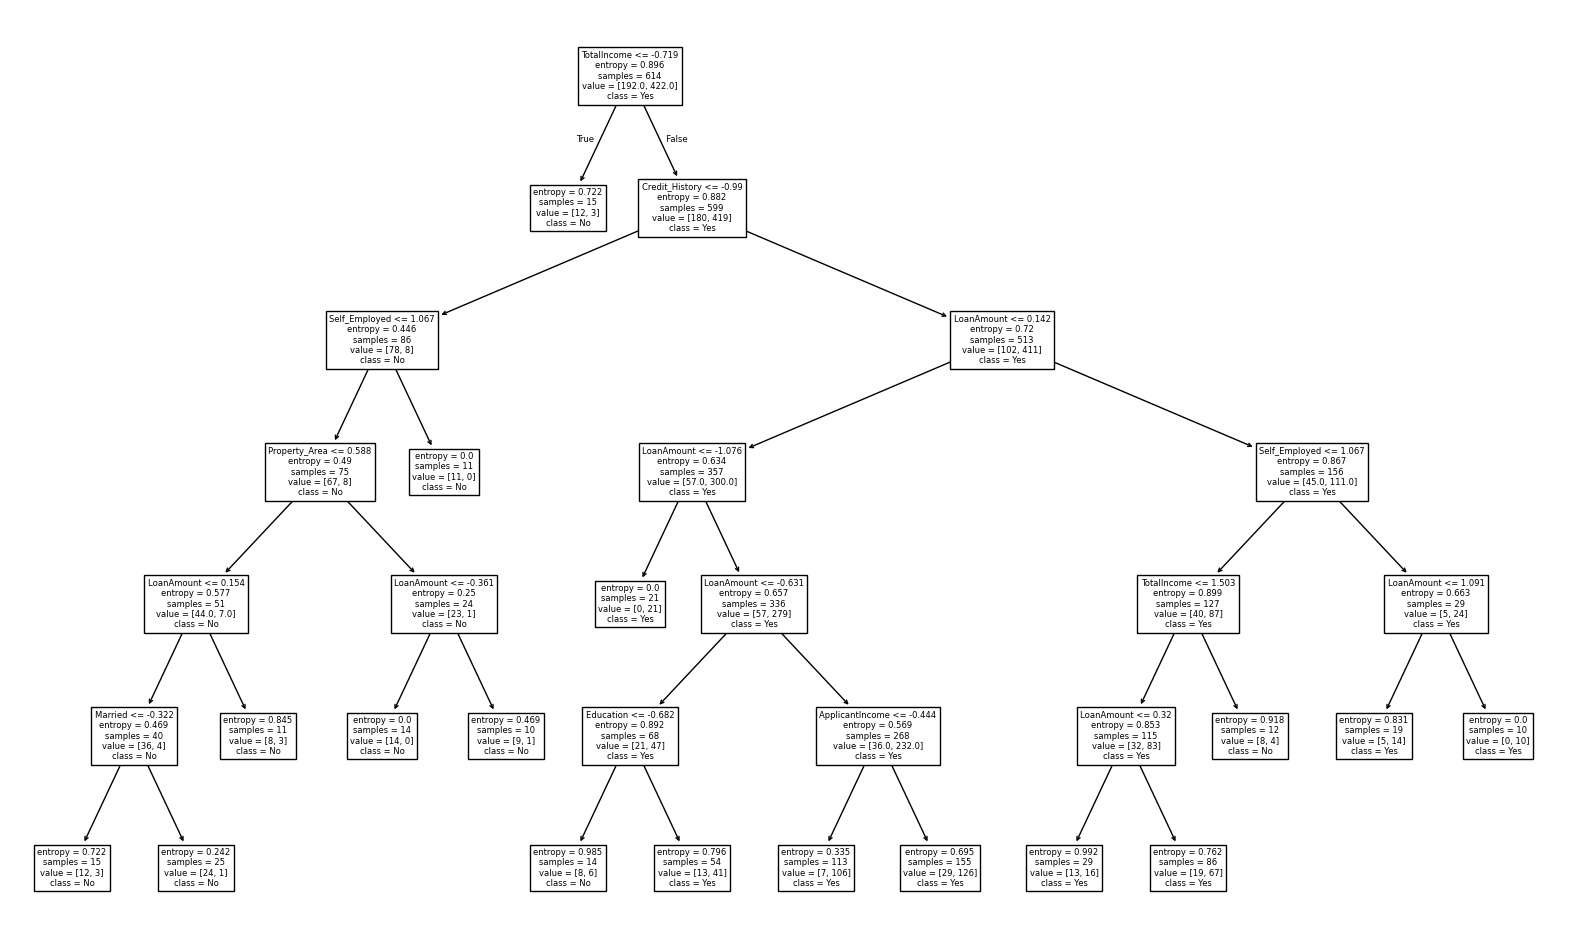

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))

plot_tree(
    pruned_tree,
    feature_names=list(x_train.columns),  
    class_names=["No", "Yes"],  
)

plt.show()

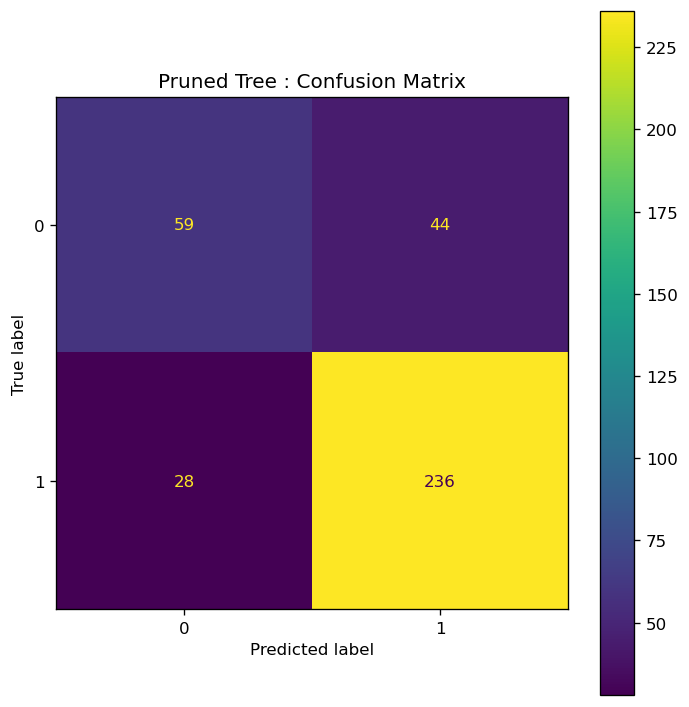

In [58]:
y_pred = pruned_tree.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pruned_tree.classes_)

disp.plot(
    ax=ax
)

ax.set_title("Pruned Tree : Confusion Matrix")
plt.tight_layout()
plt.show()

            Feature  Importance
9    Credit_History    0.652341
7        LoanAmount    0.165729
11      TotalIncome    0.087805
5   ApplicantIncome    0.037251
3         Education    0.020812


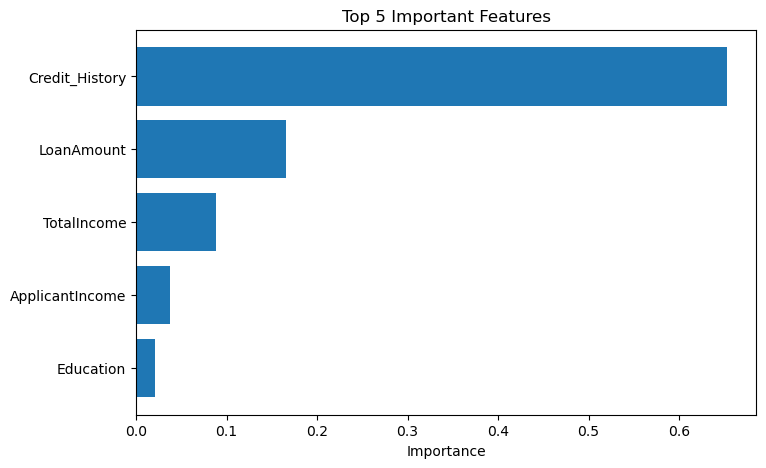

In [59]:
# finding most imp feature in decision trees 
importances = pruned_tree.feature_importances_
feature_names = x_test.columns
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
top_features = feature_importances.sort_values(by='Importance', ascending=False).head(5)

print(top_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.title("Top 5 Important Features")
plt.gca().invert_yaxis()
plt.show()



In [60]:
# Credit History is much more important than other features -> this supports our heatmap conclusion 

In [61]:
# random forest 

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # taking 100 decision trees at once 

rf_model.fit(x_train_scaled, y_train)

y_train_pred = rf_model.predict(x_train_scaled)
y_test_pred = rf_model.predict(x_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Score (Random Forest):", train_accuracy)
print("Testing Score (Random Forest):", test_accuracy)

Training Score (Random Forest): 1.0
Testing Score (Random Forest): 0.8228882833787466


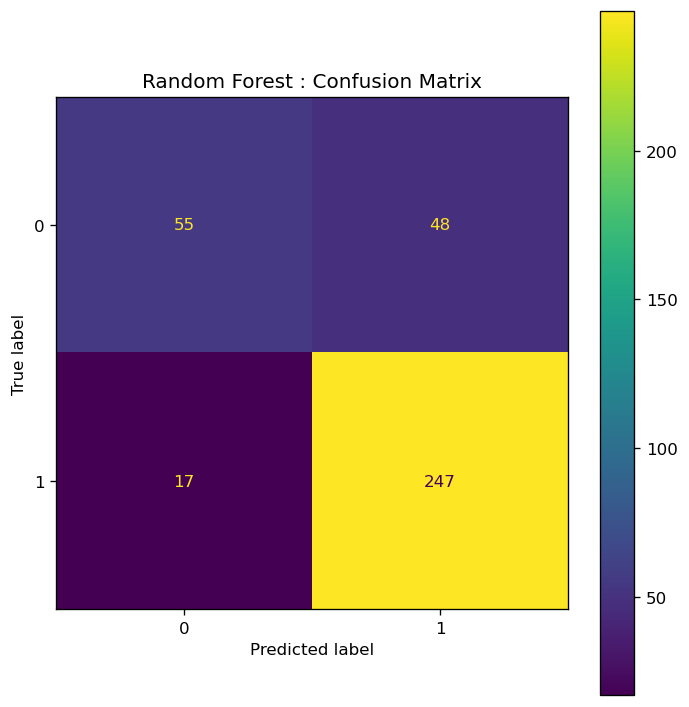

In [63]:
y_pred =rf_model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

disp.plot(
    ax=ax
)

ax.set_title("Random Forest : Confusion Matrix")
plt.tight_layout()
plt.show()

              Feature  Importance
9      Credit_History    0.255502
11        TotalIncome    0.168479
7          LoanAmount    0.148168
5     ApplicantIncome    0.146633
6   CoapplicantIncome    0.090719


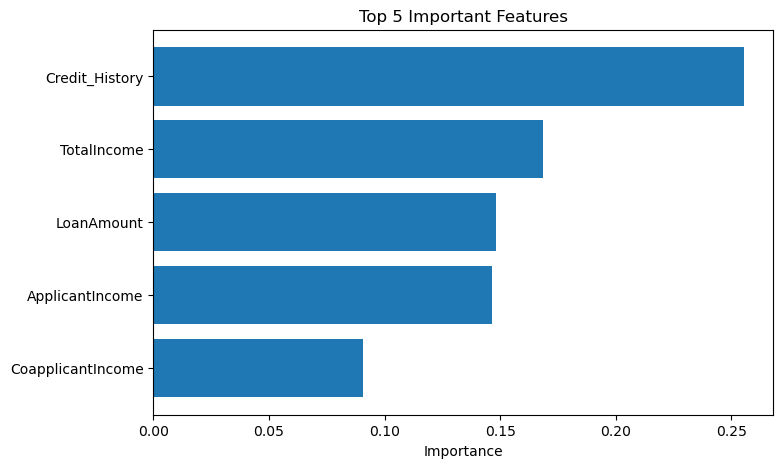

In [64]:
importances = rf_model.feature_importances_
feature_names = x_test.columns
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
top_features = feature_importances.sort_values(by='Importance', ascending=False).head(5)

print(top_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.title("Top 5 Important Features")
plt.gca().invert_yaxis()
plt.show()


In [65]:
# Credit History being the most imp remains the same.. this model mostly uses numerical features 

In [66]:
# increased accuracy (0.822888) -> this was expected

In [67]:
# KNN model

In [68]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

score_train_knn = knn_model.score(x_train_scaled, y_train)
score_test_knn = knn_model.score(x_test_scaled, y_test)

print("Training Score (KNN):", score_train_knn)
print("Testing Score (KNN):", score_test_knn)

Training Score (KNN): 0.8175895765472313
Testing Score (KNN): 0.8256130790190735


In [69]:
# increased accuracy ! (0.825613)

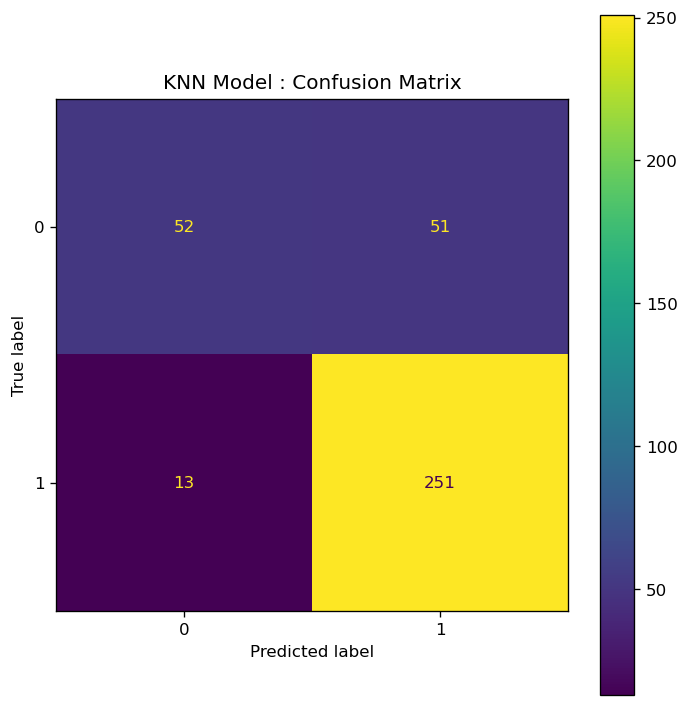

In [70]:
y_pred = knn_model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)

disp.plot(
    ax=ax
)

ax.set_title("KNN Model : Confusion Matrix")
plt.tight_layout()
plt.show()

In [71]:
# XGBoost (Extreme Gradient Boosting) -> makes decision trees sequentially, corrects errors in previous model

In [72]:
!pip install xgboost
from xgboost import XGBClassifier

In [73]:
test_df['TotalIncome'] = test_df['ApplicantIncome'] + test_df['CoapplicantIncome']

y_train_int = data['Loan_Status'].astype(int)
y_test_int = test_df['Loan_Status'].astype(int)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(x_train_scaled, y_train_int)


score_train_xgb = xgb_model.score(x_train_scaled, y_train_int)
score_test_xgb = xgb_model.score(x_test_scaled, y_test_int)

print("Training Score (XGBoost):", score_train_xgb)
print("Testing Score (XGBoost):", score_test_xgb)

Training Score (XGBoost): 0.8599348534201955
Testing Score (XGBoost): 0.8310626702997275


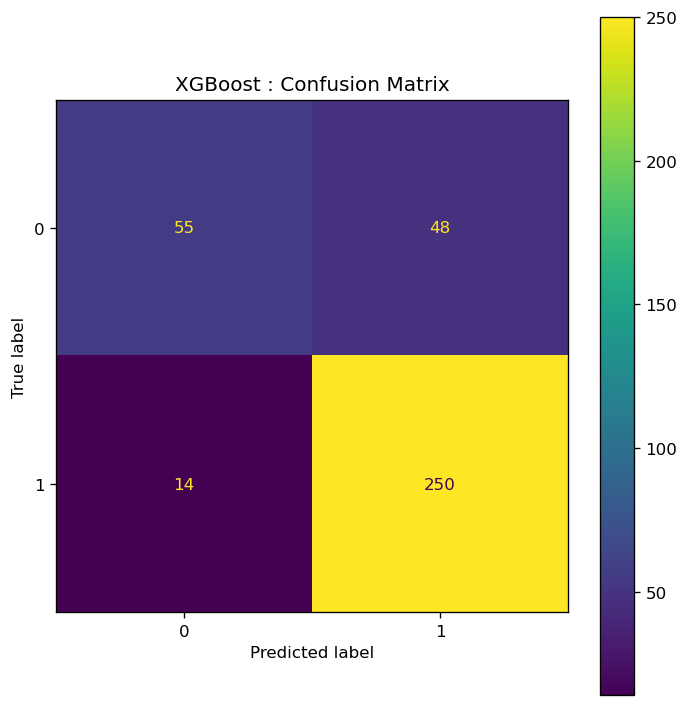

In [74]:
y_pred = xgb_model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)

disp.plot(
    ax=ax
)

ax.set_title("XGBoost : Confusion Matrix")
plt.tight_layout()
plt.show()

In [75]:
# increased accuracy ! (0.831062)

In [76]:
# svm model (support vector machine)

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

svm_model.fit(x_train_scaled, y_train_int)

score_train_svm = svm_model.score(x_train_scaled, y_train_int)
score_test_svm = svm_model.score(x_test_scaled, y_test_int)

print("Training Score (SVM):", score_train_svm)
print("Testing Score (SVM):", score_test_svm)

Training Score (SVM): 0.8273615635179153
Testing Score (SVM): 0.8528610354223434


In [78]:
# inreased accuracy ! (0.852861)

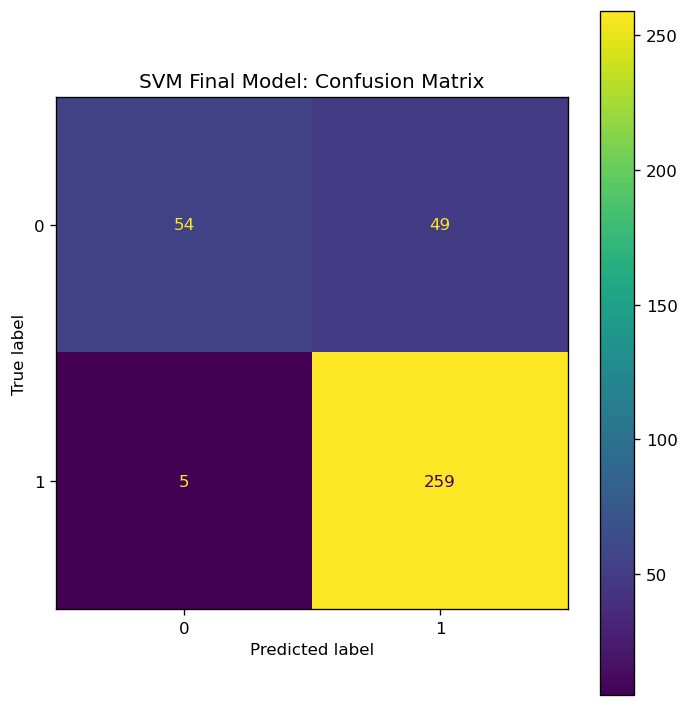

In [79]:
y_pred = svm_model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

disp.plot(
    ax=ax
)

ax.set_title("SVM Final Model: Confusion Matrix")
plt.tight_layout()
plt.show()

In [80]:
# generating accuracy, precision, recall and f1-score for all models using classification report 

In [81]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = [unpruned_tree, pruned_tree, rf_model, knn_model, xgb_model, svm_model]
model_names = [
    "Decision Tree (Unpruned)",
    "Decision Tree (Pruned)",
    "Random Forest",
    "KNN",
    "XGBoost",
    "SVM",
]
datasets = [x_test, x_test, x_test, x_test_scaled, x_test, x_test_scaled]


for name, model, x_matrix in zip(model_names, models, datasets):
   
    y_pred = model.predict(x_matrix)

    acc = accuracy_score(y_test_int, y_pred)
    prec = precision_score(y_test_int, y_pred, zero_division=0)
    rec = recall_score(y_test_int, y_pred)
    f1 = f1_score(y_test_int, y_pred)

    
    print(f"CLASSIFICATION REPORT {name}")
    print("Accuracy:  ", acc)
    print("Precision: ", prec)
    print("Recall:    ", rec)
    print("F1-Score:  ", f1)
    print("\n")

CLASSIFICATION REPORT Decision Tree (Unpruned)
Accuracy:   0.4768392370572207
Precision:  0.7307692307692307
Recall:     0.4318181818181818
F1-Score:   0.5428571428571428


CLASSIFICATION REPORT Decision Tree (Pruned)
Accuracy:   0.28065395095367845
Precision:  0.0
Recall:     0.0
F1-Score:   0.0


CLASSIFICATION REPORT Random Forest
Accuracy:   0.42779291553133514
Precision:  0.725
Recall:     0.32954545454545453
F1-Score:   0.453125


CLASSIFICATION REPORT KNN
Accuracy:   0.8446866485013624
Precision:  0.839344262295082
Recall:     0.9696969696969697
F1-Score:   0.8998242530755711


CLASSIFICATION REPORT XGBoost
Accuracy:   0.6076294277929155
Precision:  0.8448275862068966
Recall:     0.5568181818181818
F1-Score:   0.6712328767123288


CLASSIFICATION REPORT SVM
Accuracy:   0.8528610354223434
Precision:  0.8409090909090909
Recall:     0.9810606060606061
F1-Score:   0.9055944055944056




C:\Users\anves\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\anves\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\anves\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [82]:
# feature imp in svm model : doesn't have feature_importances_ since complex model created

In [83]:
# we perform permutation importance : takes 1 column and messes it up to see impact 

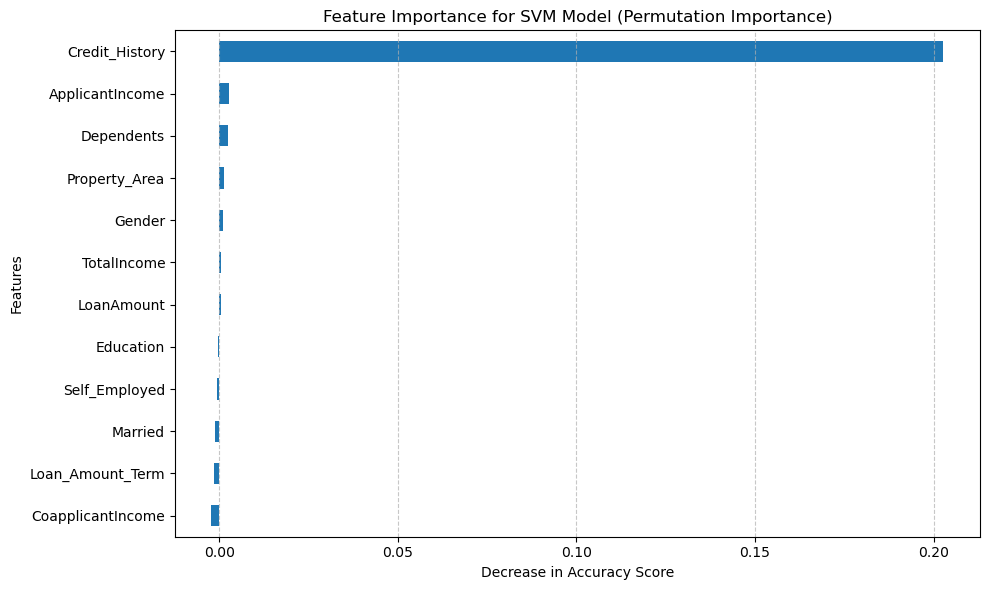

In [84]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_model, x_test_scaled, y_test_int, n_repeats=10, random_state=42
)

svm_importances = pd.Series(result.importances_mean, index=x_train.columns)

svm_importances = svm_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
svm_importances.plot(kind="barh")
plt.title("Feature Importance for SVM Model (Permutation Importance)")
plt.xlabel("Decrease in Accuracy Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [85]:
# credit history comes out as a very important feature 

In [86]:
# optional task

In [87]:
# we will use a method called K-means (K here signifies the number of clusters)

In [88]:
# to determine how many grps to make we will use elbow method (sees the point where most benefit) and silhouette score (measures tightness of each cluster)

C:\Users\anves\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\anves\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\anves\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anves\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

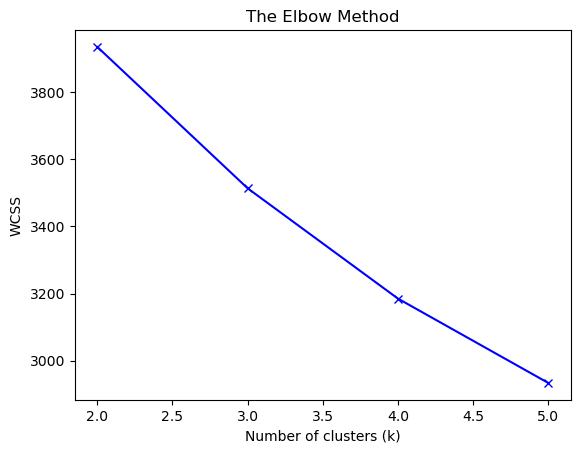

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = [] # Within-Cluster Sum of Squares -> tightness of data points 
silhouette_avg = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # 10 times program is run
    cluster_labels = kmeans.fit_predict(x_test_scaled)
    # finds centroid of each grp -> sum of squares of distance 
    wcss.append(kmeans.inertia_) # total sum for all groups is inertia 
    silhouette_avg.append(silhouette_score(x_test_scaled, cluster_labels))

# Plotting 
plt.plot(K_range, wcss, 'bx-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [90]:
# not exactly getting a minima, let's measure silhoutte score 

In [91]:
sil_scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_test_scaled)
    score = silhouette_score(x_test_scaled, labels)
    sil_scores.append(score)
    print(f"For k={k}, Silhouette Score is {score:.4f}")

C:\Users\anves\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anves\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anves\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


For k=2, Silhouette Score is 0.1277
For k=3, Silhouette Score is 0.1417
For k=4, Silhouette Score is 0.1603
For k=5, Silhouette Score is 0.1673


C:\Users\anves\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [92]:
# k=4 is the best option 

In [93]:
print("Original data shape:", data.shape)
print("Scaled data shape:  ", x_test_scaled.shape)

Original data shape: (614, 14)
Scaled data shape:   (367, 12)


C:\Users\anves\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Labels successfully attached to unscaled x_test DataFrame

1. Characterizing clusters (unscaled mean profiles)
         ApplicantIncome  CoapplicantIncome  LoanAmount   TotalIncome
Cluster                                                              
0            4364.693548        1563.021505  138.964516   5927.715054
1           17820.733333        6581.933333  266.200000  24402.666667
2            3839.546154        1042.161538  117.960000   4881.707692
3            5149.166667        1419.527778  139.083333   6568.694444

2. Credit History and Education for each cluster (Averages)
         Credit_History  Education
Cluster                           
0             82.258065  73.118280
1             93.333333  93.333333
2             82.307692  80.769231
3             94.444444  77.777778

3. Loan Approval rates per cluster
Cluster
0    76.344086
1    66.666667
2    64.615385
3    77.777778
Name: Loan_Status_Actual, dtype: float64
Cluster
0    186
2    130
3     36
1     15
Name: cou

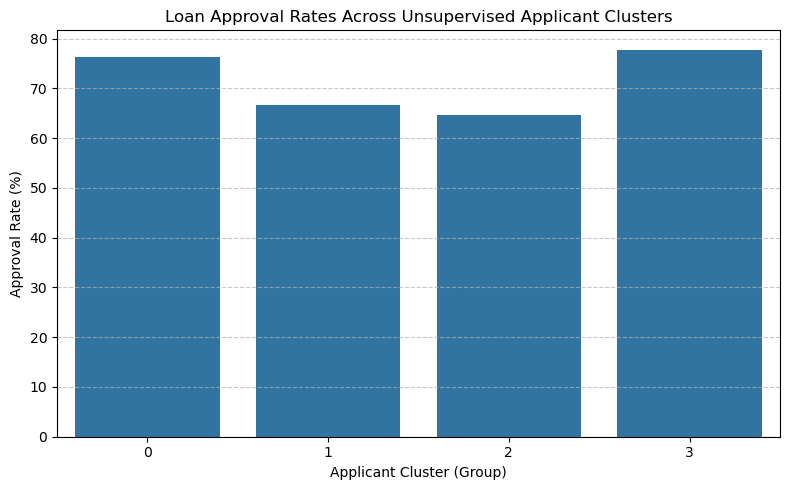

In [94]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(x_test_scaled)

x_test['Cluster'] = cluster_labels

x_test['Loan_Status_Actual'] = y_test_int

print("Labels successfully attached to unscaled x_test DataFrame")

print("\n1. Characterizing clusters (unscaled mean profiles)")
numerical_profile = x_test.groupby('Cluster')[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']].mean()
print(numerical_profile)

print("\n2. Credit History and Education for each cluster (Averages)")
category_profile = x_test.groupby('Cluster')[['Credit_History', 'Education']].mean() * 100
print(category_profile)

print("\n3. Loan Approval rates per cluster")
approval_trends = x_test.groupby('Cluster')['Loan_Status_Actual'].mean() * 100
print(approval_trends)

cluster_counts=x_test['Cluster'].value_counts()
print(cluster_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=approval_trends.index, y=approval_trends.values)
plt.title('Loan Approval Rates Across Unsupervised Applicant Clusters')
plt.xlabel('Applicant Cluster (Group)')
plt.ylabel('Approval Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

